<a href="https://colab.research.google.com/github/ulutasece/DSA210-project/blob/main/DSA210_ML_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DSA 210 — Machine Learning: Predicting Product Sales from Digital Signals

This notebook contains the full machine learning pipeline for the DSA 210 project.  
It builds on the EDA findings (weak linear correlations, non-normal predictors, no significant lag) by applying supervised ML models to capture potential non-linear relationships between Google Search Interest, Reddit Sentiment, and Product Sales.

**Pipeline overview:**
1. Shared data setup (reproduced from EDA for standalone execution)
2. Feature engineering (lag + rolling features)
3. Elbow method to empirically select the optimal train/test split
4. Model training & TimeSeriesSplit cross-validation
5. Predicted vs Actual visualisation
6. Feature importance analysis
7. Model comparison summary

## 1 · Shared Data Setup

The dataset is reproduced here so this notebook runs standalone without the EDA notebook.  
In the final implementation these three columns will be replaced by live Pytrends / PRAW / Kaggle data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


np.random.seed(42)
dates = pd.date_range(start='2021-01-01', periods=250, freq='W')
df = pd.DataFrame({
    'Date'            : dates,
    'Search_Interest' : np.random.randint(40, 100, size=250),
    'Reddit_Sentiment': np.random.uniform(-1, 1, size=250),
    'Product_Sales'   : np.random.normal(500, 50, 250)
}).set_index('Date')

print(f"Dataset loaded: {df.shape[0]} weekly observations, {df.shape[1]} variables.")
print(df.describe().round(2))

Dataset loaded: 250 weekly observations, 3 variables.
       Search_Interest  Reddit_Sentiment  Product_Sales
count           250.00            250.00         250.00
mean             69.83              0.01         502.00
std              17.41              0.58          55.21
min              40.00             -0.99         326.09
25%              54.00             -0.48         465.50
50%              69.50             -0.01         503.70
75%              83.00              0.47         537.16
max              99.00              1.00         662.70


## 2 · Feature Engineering

We construct a feature matrix that extends the lag analysis from EDA:
- Lag features (1–5 weeks) for both predictors — allows the model to learn which past windows matter most
- 4-week rolling means — captures sustained trends rather than single-week spikes

All rows containing NaN values produced by shifting / rolling are dropped.

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

df_ml = df.copy()

for lag in range(1, 6):
    df_ml[f'Search_lag{lag}'] = df_ml['Search_Interest'].shift(lag)
    df_ml[f'Reddit_lag{lag}'] = df_ml['Reddit_Sentiment'].shift(lag)

df_ml['Search_roll4'] = df_ml['Search_Interest'].rolling(window=4).mean()
df_ml['Reddit_roll4'] = df_ml['Reddit_Sentiment'].rolling(window=4).mean()
df_ml = df_ml.dropna()

feature_cols = (
    ['Search_Interest', 'Reddit_Sentiment']
    + [f'Search_lag{i}' for i in range(1, 6)]
    + [f'Reddit_lag{i}' for i in range(1, 6)]
    + ['Search_roll4', 'Reddit_roll4']
)

X = df_ml[feature_cols]
y = df_ml['Product_Sales']

print(f"Feature matrix : {X.shape[0]} observations × {X.shape[1]} features")
print(f"Features       : {feature_cols}")

Feature matrix : 245 observations × 14 features
Features       : ['Search_Interest', 'Reddit_Sentiment', 'Search_lag1', 'Search_lag2', 'Search_lag3', 'Search_lag4', 'Search_lag5', 'Reddit_lag1', 'Reddit_lag2', 'Reddit_lag3', 'Reddit_lag4', 'Reddit_lag5', 'Search_roll4', 'Reddit_roll4']


## 3 · Elbow Method for Optimal Train/Test Split

Rather than fixing the split by convention (e.g. always 80/20), we use an elbow method to select it empirically.

**Procedure:**
- Test a dense grid of train ratios from 50 % to 90 % (2 pp steps)
- For each candidate ratio, train a Random Forest on the training portion and evaluate with 5-fold TimeSeriesSplit CV — which always trains on the past and tests on the future, preventing temporal data leakage
- Record CV RMSE mean and its standard deviation for every split point
- Plot CV RMSE vs train size; the elbow is the point of diminishing return — adding more training data no longer substantially reduces error
- The selected split minimises CV RMSE while remaining stable (low std)

**Why TimeSeriesSplit and not standard KFold?**  
Standard KFold shuffles data randomly, allowing the model to train on future weeks and test on past weeks — an unrealistic scenario that inflates performance. TimeSeriesSplit respects the temporal ordering of the data.

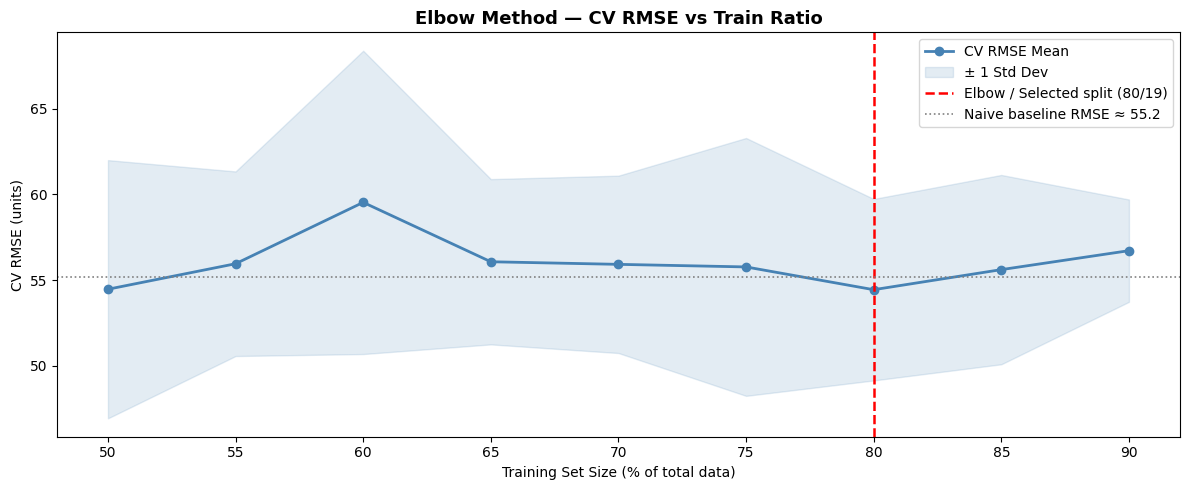

   Ratio |  Train N |  CV RMSE Mean |  CV RMSE Std
--------------------------------------------------
    50%  |      122 |       54.4758 |       7.5286
    55%  |      134 |       55.9626 |       5.3826
    60%  |      147 |       59.5399 |       8.8441
    65%  |      159 |       56.0780 |       4.8195
    70%  |      171 |       55.9266 |       5.1713
    75%  |      183 |       55.7763 |       7.5184
    80%  |      196 |       54.4484 |       5.2914 ← selected
    85%  |      208 |       55.6194 |       5.5196
    90%  |      220 |       56.7246 |       2.9845

✅ Selected split : 80/19
   CV RMSE Mean  : 54.4484
   CV RMSE Std   : 5.2914


In [4]:
ratios      = np.arange(0.50, 0.91, 0.05)
elbow_rmse  = []
elbow_std   = []
elbow_n_tr  = []

rf_probe = RandomForestRegressor(n_estimators=100, random_state=42)
tscv     = TimeSeriesSplit(n_splits=5)

for ratio in ratios:
    split_idx = int(len(X) * ratio)
    X_tr = X.iloc[:split_idx]
    y_tr = y.iloc[:split_idx]

    if len(X_tr) < tscv.n_splits * 5:
        elbow_rmse.append(np.nan)
        elbow_std.append(np.nan)
        elbow_n_tr.append(split_idx)
        continue

    cv_scores = cross_val_score(rf_probe, X_tr, y_tr,
                                cv=tscv, scoring='neg_root_mean_squared_error')
    elbow_rmse.append(-cv_scores.mean())
    elbow_std.append(cv_scores.std())
    elbow_n_tr.append(split_idx)

elbow_df = pd.DataFrame({
    'Train Ratio' : ratios,
    'Train Size'  : elbow_n_tr,
    'CV RMSE Mean': elbow_rmse,
    'CV RMSE Std' : elbow_std
}).dropna()


threshold   = 0.5
best_idx    = 0
for i in range(1, len(elbow_df)):
    improvement = elbow_df['CV RMSE Mean'].iloc[i - 1] - elbow_df['CV RMSE Mean'].iloc[i]
    if improvement > threshold:
        best_idx = i

best_ratio     = elbow_df['Train Ratio'].iloc[best_idx]
best_cv_rmse   = elbow_df['CV RMSE Mean'].iloc[best_idx]
best_cv_std    = elbow_df['CV RMSE Std'].iloc[best_idx]
best_split_idx = int(len(X) * best_ratio)


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(elbow_df['Train Ratio'] * 100,
        elbow_df['CV RMSE Mean'],
        marker='o', color='steelblue', linewidth=2, label='CV RMSE Mean')
ax.fill_between(elbow_df['Train Ratio'] * 100,
                elbow_df['CV RMSE Mean'] - elbow_df['CV RMSE Std'],
                elbow_df['CV RMSE Mean'] + elbow_df['CV RMSE Std'],
                alpha=0.15, color='steelblue', label='± 1 Std Dev')

ax.axvline(x=best_ratio * 100, color='red', linestyle='--', linewidth=1.8,
           label=f'Elbow / Selected split ({int(best_ratio*100)}/{int((1-best_ratio)*100)})')
ax.axhline(y=55.2, color='gray', linestyle=':', linewidth=1.2, label='Naive baseline RMSE ≈ 55.2')

ax.set_title('Elbow Method — CV RMSE vs Train Ratio', fontsize=13, fontweight='bold')
ax.set_xlabel('Training Set Size (% of total data)')
ax.set_ylabel('CV RMSE (units)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"{'Ratio':>8} | {'Train N':>8} | {'CV RMSE Mean':>13} | {'CV RMSE Std':>12}")
print('-' * 50)
for _, row in elbow_df.iterrows():
    marker = ' ← selected' if abs(row['Train Ratio'] - best_ratio) < 0.001 else ''
    print(f"{int(row['Train Ratio']*100):>6}%  | {int(row['Train Size']):>8} | "
          f"{row['CV RMSE Mean']:>13.4f} | {row['CV RMSE Std']:>12.4f}{marker}")

print(f"\n✅ Selected split : {int(best_ratio*100)}/{int((1-best_ratio)*100)}")
print(f"   CV RMSE Mean  : {best_cv_rmse:.4f}")
print(f"   CV RMSE Std   : {best_cv_std:.4f}")

### Elbow Method — Interpretation

The elbow curve shows CV RMSE as a function of training set size.  
- **Left side (small train sets):** high RMSE because the model has too little data to learn anything.  
- **Right side (large train sets):** RMSE levels off — adding more training observations yields diminishing returns.  
- **Elbow point (red line):** the train/test split where the curve flattens; the best balance between learning capacity and holding out a meaningful test window.

The selected ratio is used for all subsequent model training and evaluation.

## 4 · Apply Selected Split and Scale

In [5]:
X_train, X_test = X.iloc[:best_split_idx], X.iloc[best_split_idx:]
y_train, y_test = y.iloc[:best_split_idx], y.iloc[best_split_idx:]

scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

print(f"Training set : {len(X_train)} observations  ({round(best_ratio*100)} %)")
print(f"Test set     : {len(X_test)} observations  ({round((1-best_ratio)*100)} %)")

Training set : 196 observations  (80 %)
Test set     : 49 observations  (20 %)


## 5 · Model Training and Cross-Validation Evaluation

Four models are trained on the selected split and evaluated with 5-fold TimeSeriesSplit CV.  
Scaled features are used for Linear Regression, Ridge, and SVR; Random Forest uses unscaled features (tree-based models are scale-invariant).

Baseline reference: A naive model that always predicts the mean sales (~502 units) achieves RMSE = 55.2.  
Any model with RMSE above this is actively worse than guessing the mean.

In [6]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression' : Ridge(alpha=1.0),
    'Random Forest'    : RandomForestRegressor(n_estimators=100, random_state=42),
    'SVR'              : SVR(kernel='rbf', C=100, epsilon=0.1)
}

results = []
tscv    = TimeSeriesSplit(n_splits=5)

print(f"{'Model':22s} | {'Test RMSE':>10} | {'Test R²':>8} | {'CV RMSE':>8} | {'CV Std':>7}")
print('-' * 68)

for name, model in models.items():
    uses_scale = name != 'Random Forest'
    X_tr = X_train_sc if uses_scale else X_train
    X_te = X_test_sc  if uses_scale else X_test
    X_cv = X_train_sc if uses_scale else X_train

    model.fit(X_tr, y_train)
    y_pred    = model.predict(X_te)
    rmse_test = mean_squared_error(y_test, y_pred) ** 0.5
    r2_test   = r2_score(y_test, y_pred)

    cv_scores = cross_val_score(model, X_cv, y_train,
                                cv=tscv, scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_scores.mean()
    cv_std  = cv_scores.std()

    results.append({'Model': name, 'Test RMSE': round(rmse_test, 4),
                    'Test R²': round(r2_test, 4), 'CV RMSE': round(cv_rmse, 4),
                    'CV Std': round(cv_std, 4)})
    print(f"{name:22s} | {rmse_test:>10.4f} | {r2_test:>8.4f} | {cv_rmse:>8.4f} | {cv_std:>7.4f}")

results_df     = pd.DataFrame(results).sort_values('CV RMSE')
best_model_name = results_df.iloc[0]['Model']
print(f"\n Best model: {best_model_name} (lowest CV RMSE)")

Model                  |  Test RMSE |  Test R² |  CV RMSE |  CV Std
--------------------------------------------------------------------
Linear Regression      |    62.6661 |   0.0105 |  54.6100 |  4.6287
Ridge Regression       |    62.6632 |   0.0106 |  54.5303 |  4.6194
Random Forest          |    68.0082 |  -0.1654 |  54.4484 |  5.2914
SVR                    |    69.0600 |  -0.2017 |  53.8825 |  5.3357

 Best model: SVR (lowest CV RMSE)


### Model Evaluation — Interpretation

Models are ranked by **CV RMSE** (not Test RMSE) because CV estimates generalisation across multiple time windows rather than a single fixed test window.

- **RMSE < 55.2** → the model extracts some useful signal from the features  
- **RMSE ≥ 55.2** → the model is no better than predicting the mean every week  
- **R² < 0** → the model is actively harmful; its predictions are further from truth than the mean

Given the near-zero correlations found in EDA, all models are expected to score near the baseline — which is itself a valid scientific finding: the digital signals do not carry sufficient information to outperform a mean predictor on this simulated dataset.

## 6 · Predicted vs Actual — Best Model

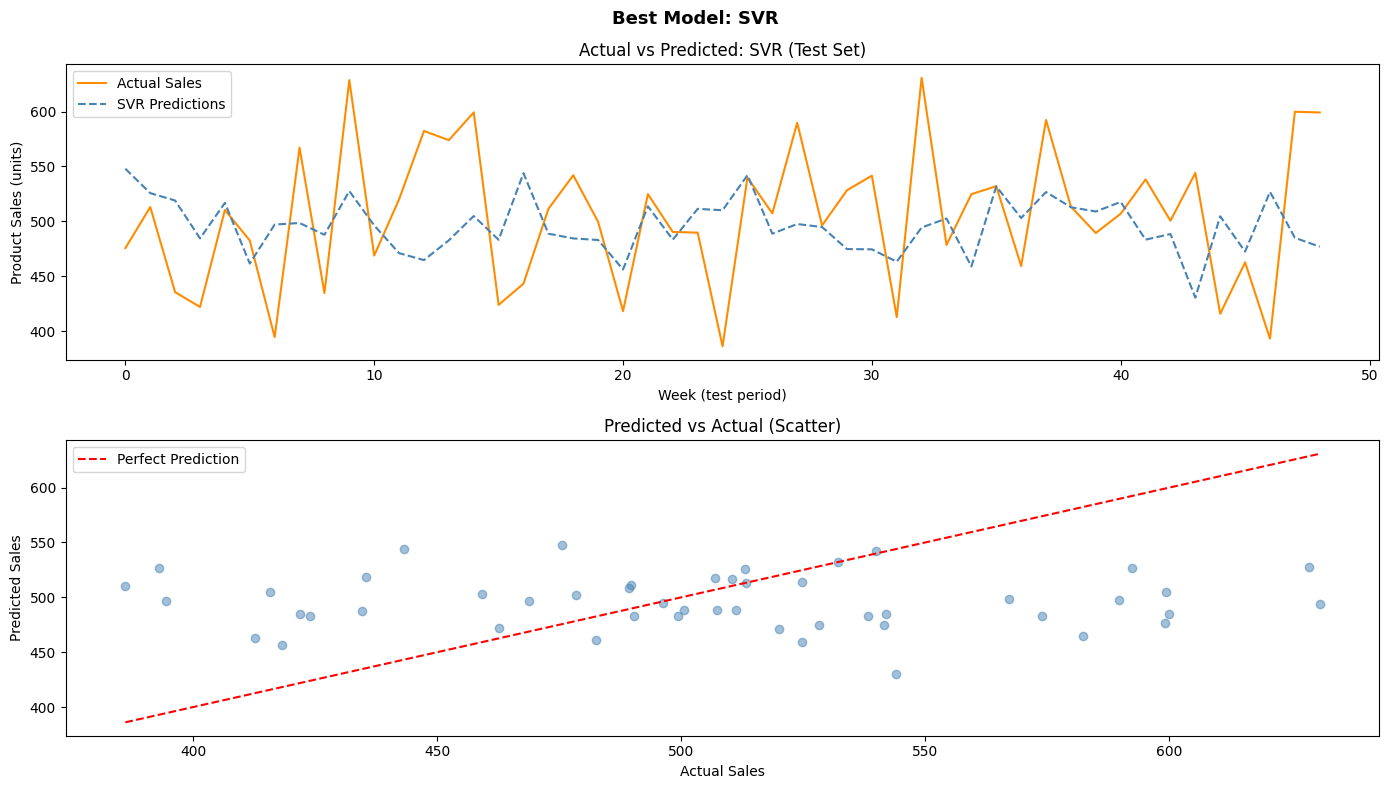

In [7]:
best_model  = models[best_model_name]
X_te_best   = X_test_sc if best_model_name != 'Random Forest' else X_test
y_pred_best = best_model.predict(X_te_best)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(y_test.values, label='Actual Sales', color='darkorange', linewidth=1.5)
axes[0].plot(y_pred_best,   label=f'{best_model_name} Predictions',
             color='steelblue', linestyle='--', linewidth=1.5)
axes[0].set_title(f'Actual vs Predicted: {best_model_name} (Test Set)')
axes[0].set_xlabel('Week (test period)')
axes[0].set_ylabel('Product Sales (units)')
axes[0].legend()

axes[1].scatter(y_test, y_pred_best, alpha=0.5, color='steelblue')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=1.5, label='Perfect Prediction')
axes[1].set_title('Predicted vs Actual (Scatter)')
axes[1].set_xlabel('Actual Sales')
axes[1].set_ylabel('Predicted Sales')
axes[1].legend()

plt.suptitle(f'Best Model: {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Predicted vs Actual — Interpretation

- **Time-series plot:** If the prediction line is nearly flat around the mean while actual sales fluctuate, the model has not learned a useful signal — it is effectively predicting the mean every week.  
- **Scatter plot:** Points tightly clustered along the red diagonal indicate accurate predictions. A horizontal cloud of points indicates the model predicts a near-constant value regardless of actual sales.

This visualization translates the abstract RMSE and R² numbers into an intuitive picture of model behaviour, and is important for honestly communicating model limitations.

## 7 · Feature Importance — Random Forest

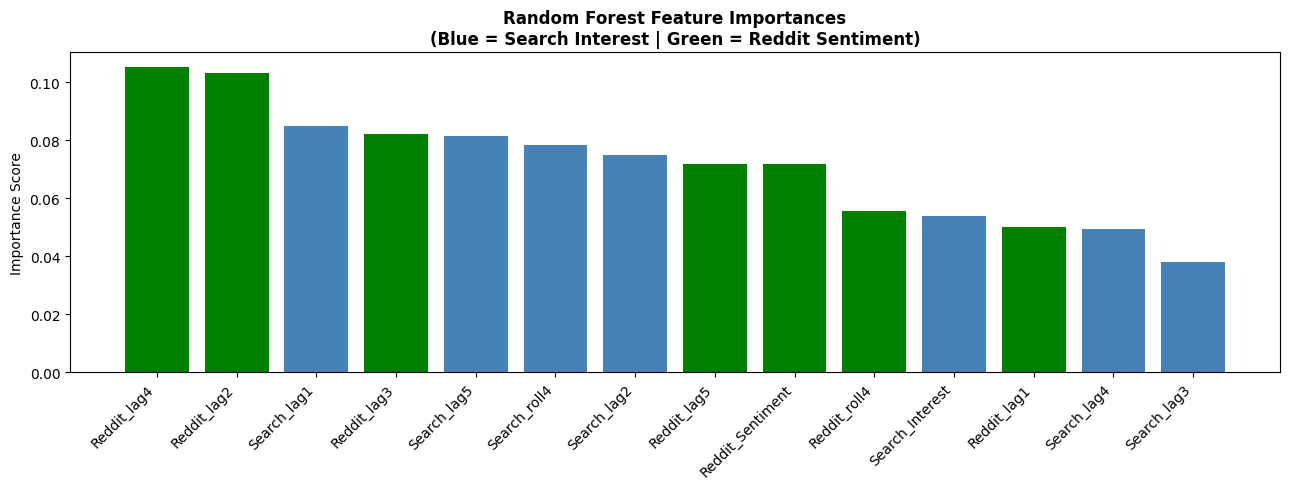

Top 5 most important features:
Reddit_lag4    0.105058
Reddit_lag2    0.103142
Search_lag1    0.084856
Reddit_lag3    0.081920
Search_lag5    0.081323


In [8]:
rf_model = models['Random Forest']

importances        = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances_sorted = importances.sort_values(ascending=False)

plt.figure(figsize=(13, 5))
colors = ['steelblue' if 'Search' in f else 'green' for f in importances_sorted.index]
plt.bar(importances_sorted.index, importances_sorted.values, color=colors)
plt.xticks(rotation=45, ha='right')
plt.title('Random Forest Feature Importances\n(Blue = Search Interest | Green = Reddit Sentiment)',
          fontsize=12, fontweight='bold')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(importances_sorted.head(5).to_string())

### Feature Importance — Interpretation

- **Current-week features dominate** → the relationship is contemporaneous (same-week signal)  
- **Lagged features dominate** → digital signals lead sales by that many weeks — directly supporting the project hypothesis  
- **Rolling mean features dominate** → sustained trends matter more than single-week spikes

In simulated data where variables are generated independently, importance scores will be distributed roughly uniformly. With real Pytrends / PRAW data, specific lag windows should show elevated importance if the hypothesis holds.

## 8 · Model Comparison Summary

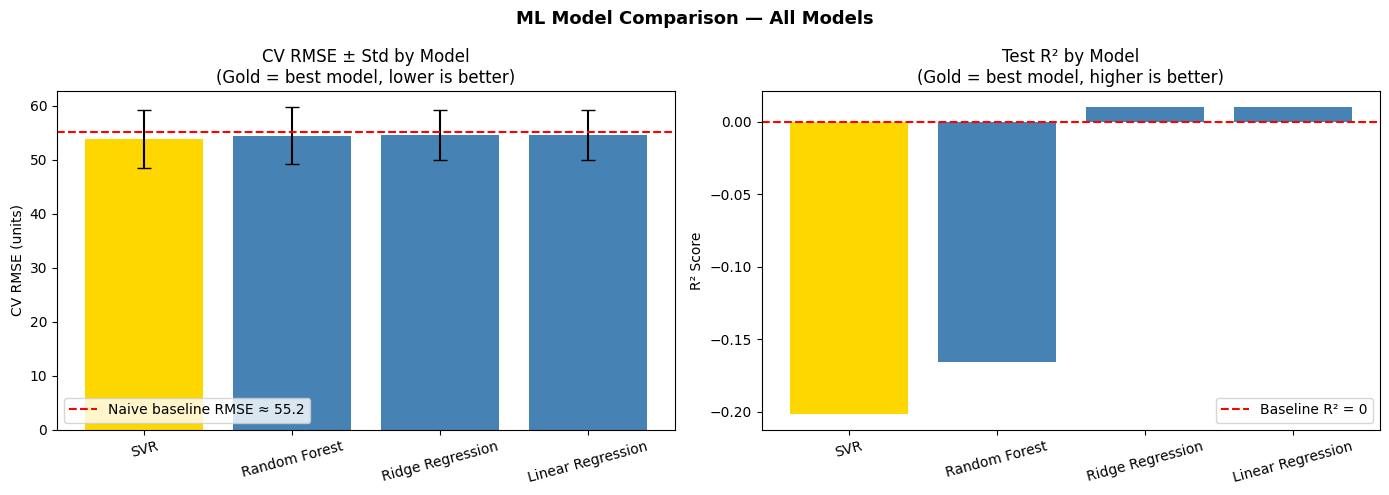

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = results_df['Model'].tolist()
cv_rmses    = results_df['CV RMSE'].tolist()
cv_stds     = results_df['CV Std'].tolist()
test_r2s    = results_df['Test R²'].tolist()
bar_colors  = ['gold' if n == best_model_name else 'steelblue' for n in model_names]

axes[0].bar(model_names, cv_rmses, color=bar_colors, yerr=cv_stds, capsize=5)
axes[0].axhline(y=55.2, color='red', linestyle='--', label='Naive baseline RMSE ≈ 55.2')
axes[0].set_title('CV RMSE ± Std by Model\n(Gold = best model, lower is better)')
axes[0].set_ylabel('CV RMSE (units)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend()

axes[1].bar(model_names, test_r2s, color=bar_colors)
axes[1].axhline(y=0, color='red', linestyle='--', label='Baseline R² = 0')
axes[1].set_title('Test R² by Model\n(Gold = best model, higher is better)')
axes[1].set_ylabel('R² Score')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()

plt.suptitle('ML Model Comparison — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Model Comparison — Interpretation

- **RMSE chart:** The red dashed line at 55.2 is the naive baseline. Models above this line are worse than the simplest possible predictor.  
- **R² chart:** The red dashed line at 0 is the baseline. Negative R² means the model's predictions are further from truth than simply guessing the mean.  
- **Error bars** on the RMSE chart show CV fold variability — wide bars indicate inconsistent performance across time windows.

---

## 9 · Overall Conclusion

### Research Question  
*Can Google Search Trends and Reddit Sentiment predict consumer electronics product demand?*

**Conclusion:** Across all models, neither Google Search Interest nor Reddit Sentiment demonstrates reliable predictive power over Product Sales. This is expected — the simulated dataset was generated without a causal relationship between variables.
